In [1]:
#import all necessary libraries and packages for the analysis
from imports import *

# Reproducing the Miltiadous preprocessing pipeline 
We will be closely replicating (to the best of our ability) the paper's pipeline to remove artifacts in the EEG. 
It cannot be exact because we are using Python, while the paper worked in EEGLAB

1. Butterworth band-pass filter: 0.5 - 45 Hz
2. Re-reference to the average of A1 and A2
3. Run ASR
4. Run ICA
5. Automatically remove ICA components labeled as eye or jaw artifacts

End goal of this notebook is to create a clean EEG version 

## 1. Butterworth band-pass filter: 0.5 - 45 Hz
<0.5 will help remove slow drift
\>45 will help remove muscle movements

In [2]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=45,
    method='iir',
    iir_params=dict(order=4,ftype='butter')
)

<RawEEGLAB | sub-001_task-eyesclosed_eeg.set, 19 x 299900 (599.8 s), ~43.5 MiB, data loaded>

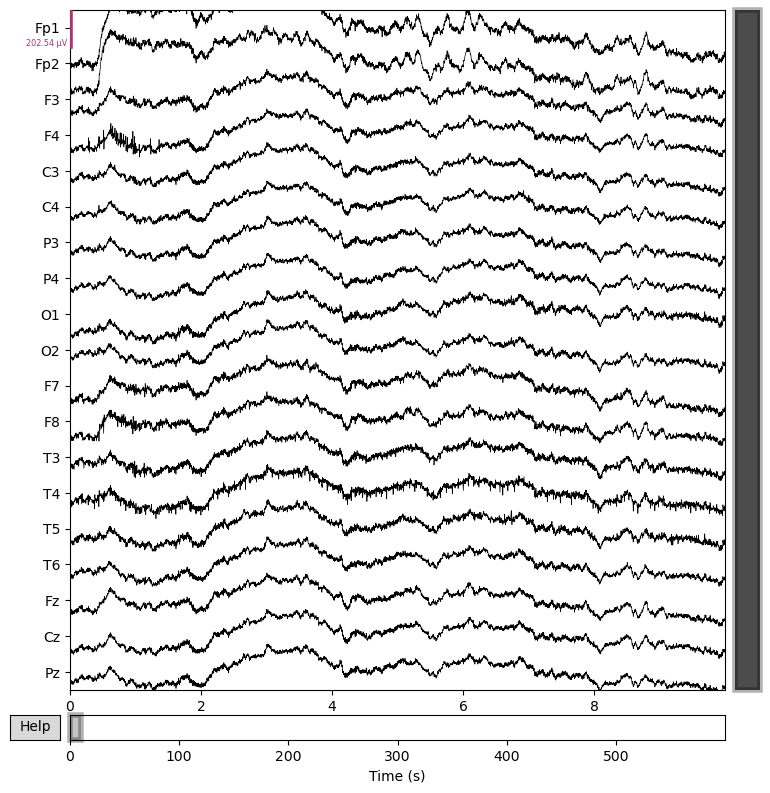

In [3]:
# visualize raw EEG
raw.plot(duration=10, scalings="auto");

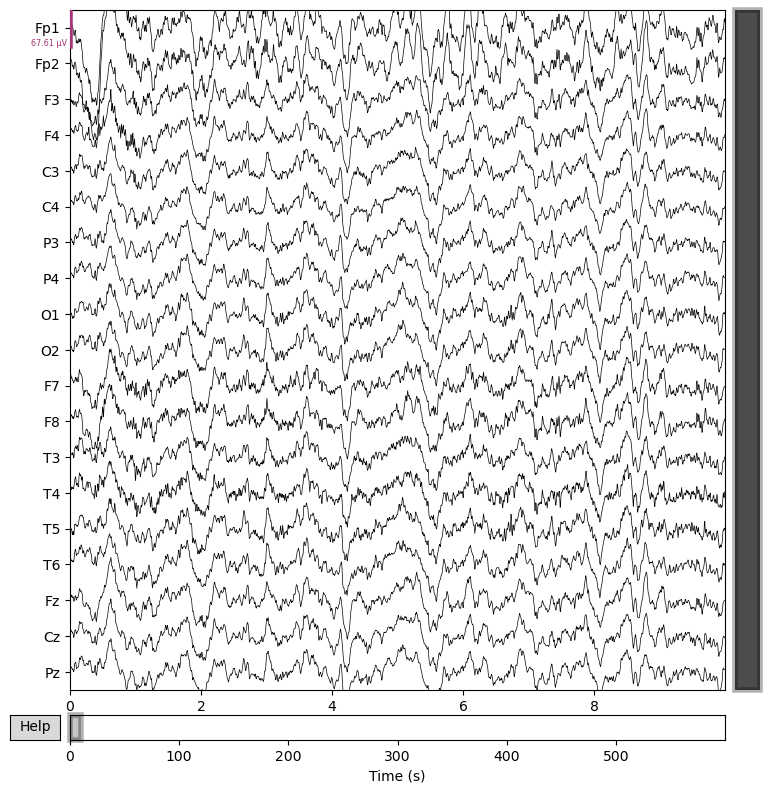

In [4]:
#visualize filtered EEG
raw_filtered.plot(duration=10, scalings="auto");

Upon observation comparing the two EEGs, unfiltered and filtered (butterworth band-pass filter), the filtered signal is slightly "cleaner" and smoother. 

Some reasons for this: 

- getting rid of high frequencies removed the small jagged spikes (making it look smoother and more defined)
- getting rid of low frequencies reduced some of the drifts(?) -not sure

However, it is not much of a difference

In [5]:
#Visualize diference by looking at the power spectrum (PSD)

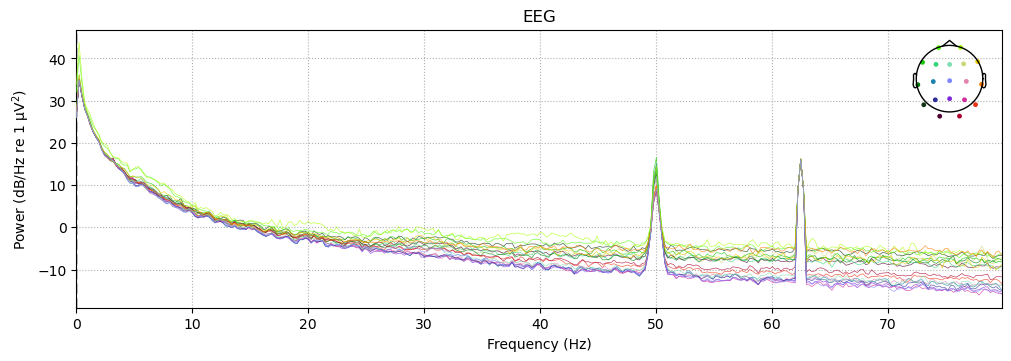

In [6]:
raw.compute_psd(fmax=80).plot()

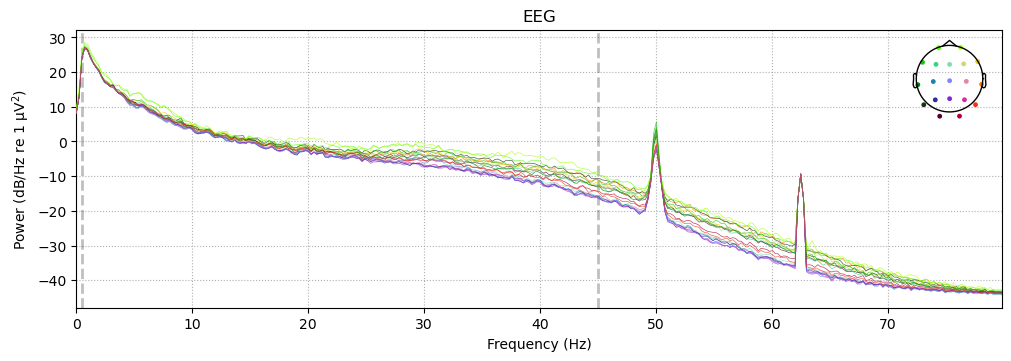

In [7]:
raw_filtered.compute_psd(fmax=80).plot()

Now comparing the power spectrum of the unfiltered vs. filtered, we can more visually see the effects of the butterworth bandpass filter. In the raw data, the power extends beyond 45 Hz. In the filtered, the power is cut off immediately t 45 Hz.

You can also notice a brief spike in the 50 Hz and 63 Hz range, this can be attributed to machine noise, electrical noise, etc. Since the bandpass filter already filters out >45 Hz, we do not have to worry about filtering this out with a Notch filter. So we will skip this filter.

## Re referencing 